<a href="https://colab.research.google.com/github/Nilamsari01/Pengolahan_Citra_Digital/blob/main/Citra_Histogram_Ijazah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

In [ ]:
uploaded = files.upload()

print("Jumlah gambar yang berhasil diupload:", len(uploaded))

for nama_file in uploaded.keys():
    print("-", nama_file)

Saving gambar9.jpg to gambar9.jpg
Saving gambar8.jpg to gambar8.jpg
Saving gambar7.jpg to gambar7.jpg
Saving gambar6.jpg to gambar6.jpg
Saving gambar5.jpg to gambar5.jpg
Saving gambar4.jpg to gambar4.jpg
Saving gambar3.jpg to gambar3.jpg
Saving gambar2.jpg to gambar2.jpg
Saving gambar1.jpg to gambar1.jpg
Jumlah gambar yang berhasil diupload: 9
- gambar9.jpg
- gambar8.jpg
- gambar7.jpg
- gambar6.jpg
- gambar5.jpg
- gambar4.jpg
- gambar3.jpg
- gambar2.jpg
- gambar1.jpg


In [ ]:
data_citra = {}

for nama_file in uploaded.keys():

    img = cv2.imread(nama_file)

    if img is None:
        print("Gagal membaca:", nama_file)
        continue

    # OpenCV membaca gambar dalam format BGR
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Konversi RGB menjadi grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    data_citra[nama_file] = {
        "rgb": rgb,
        "gray": gray
    }

print("Semua gambar berhasil diproses.")

Semua gambar berhasil diproses.


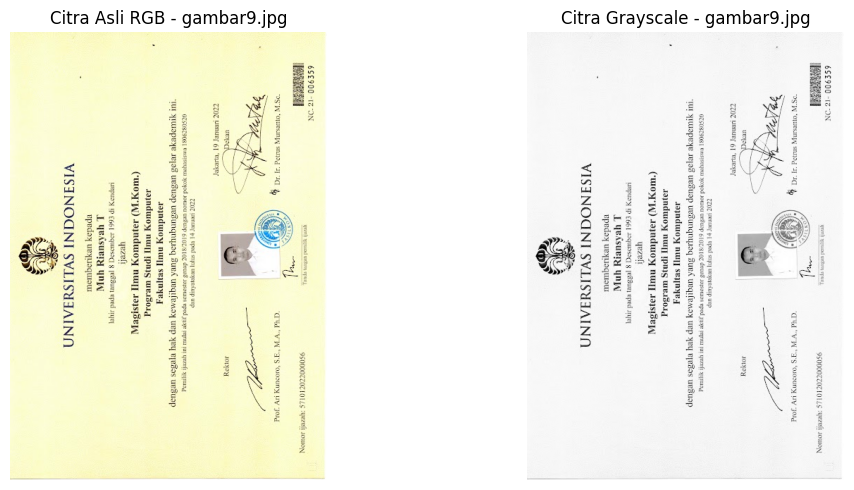

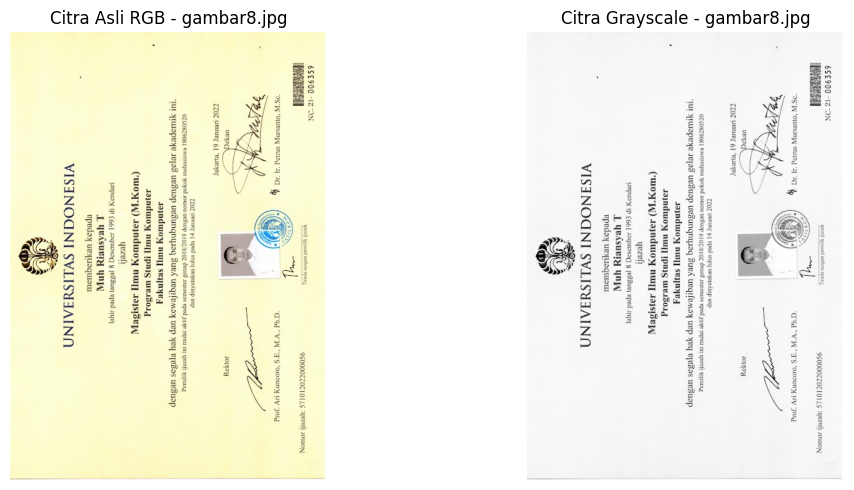

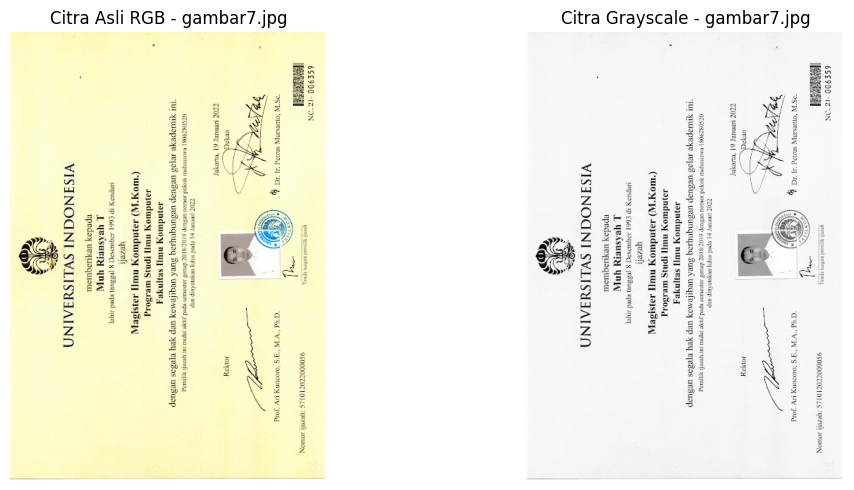

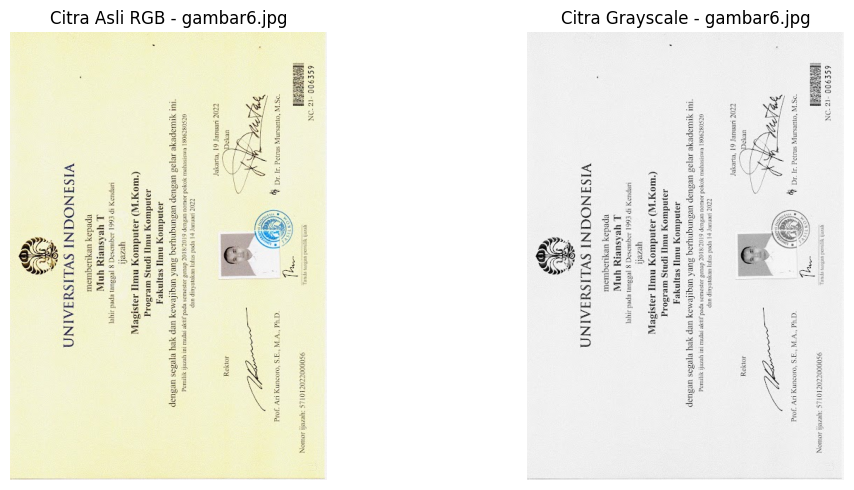

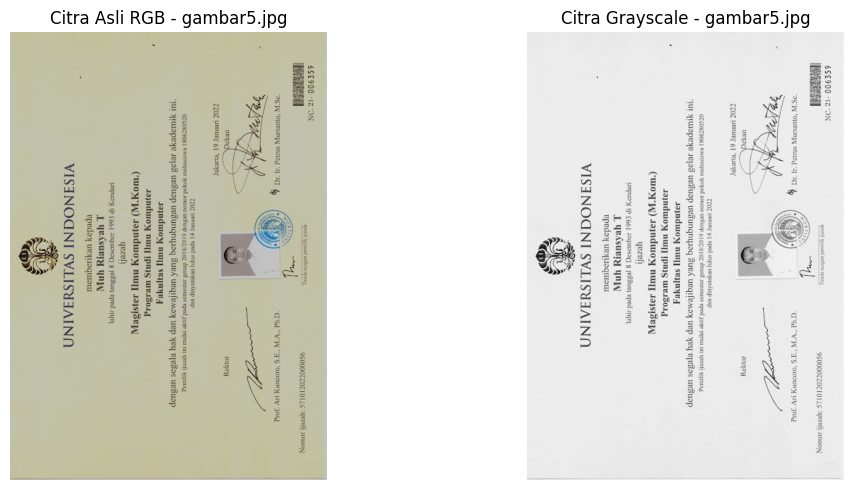

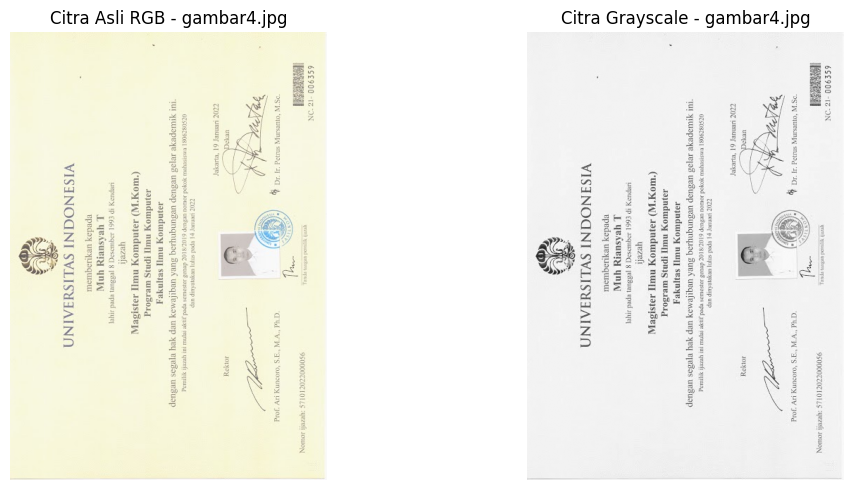

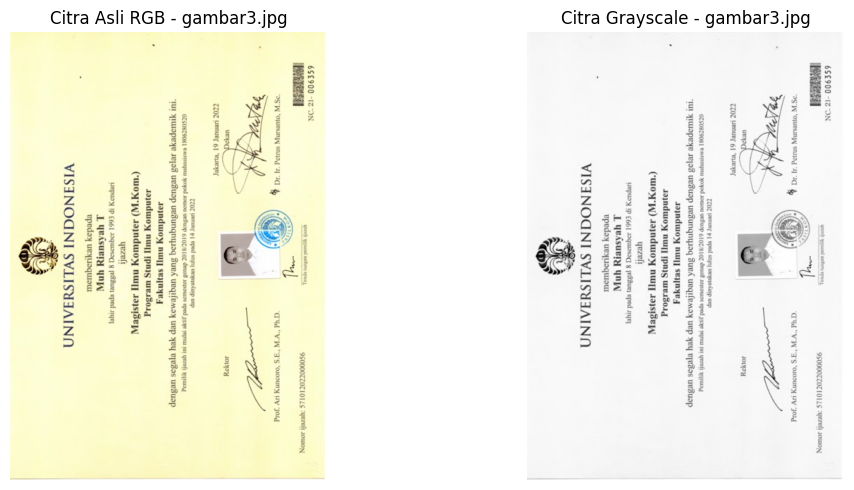

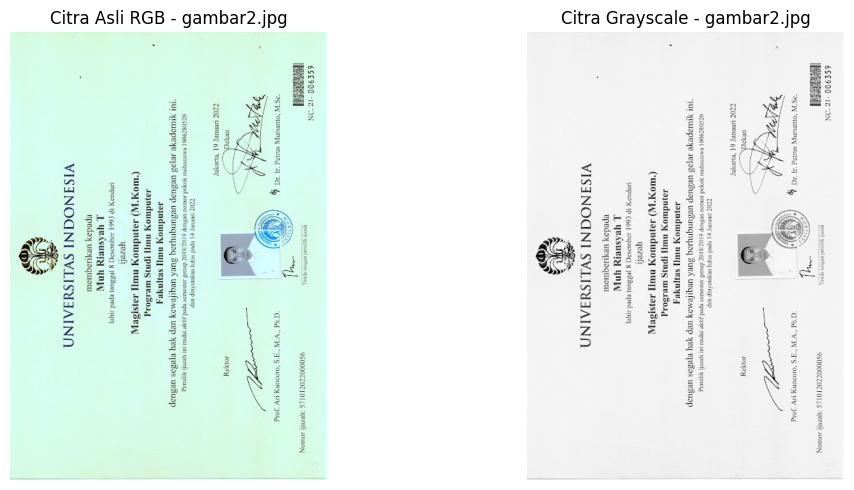

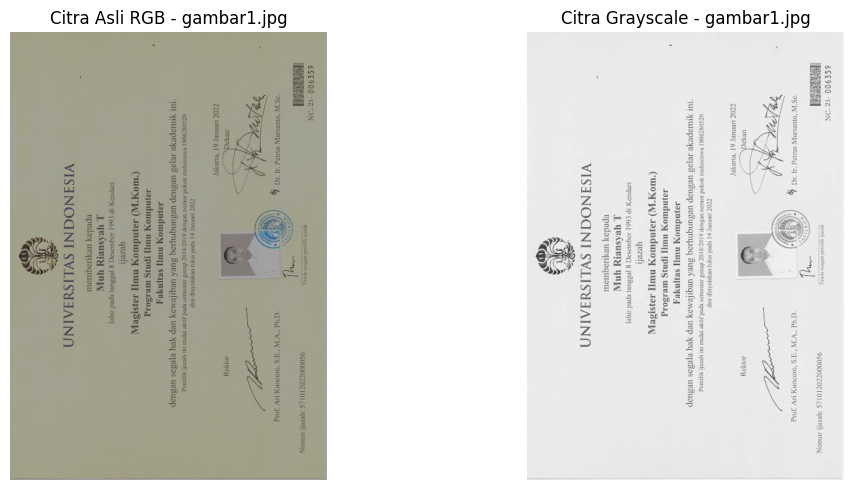

In [ ]:
for nama_file, data in data_citra.items():

    rgb = data["rgb"]
    gray = data["gray"]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Citra Asli RGB - " + nama_file)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Citra Grayscale - " + nama_file)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

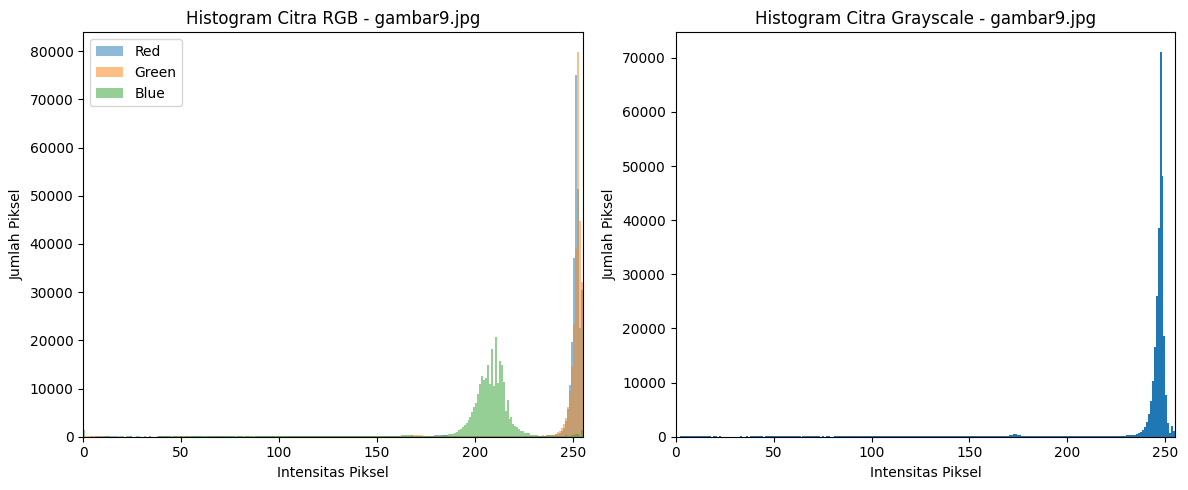

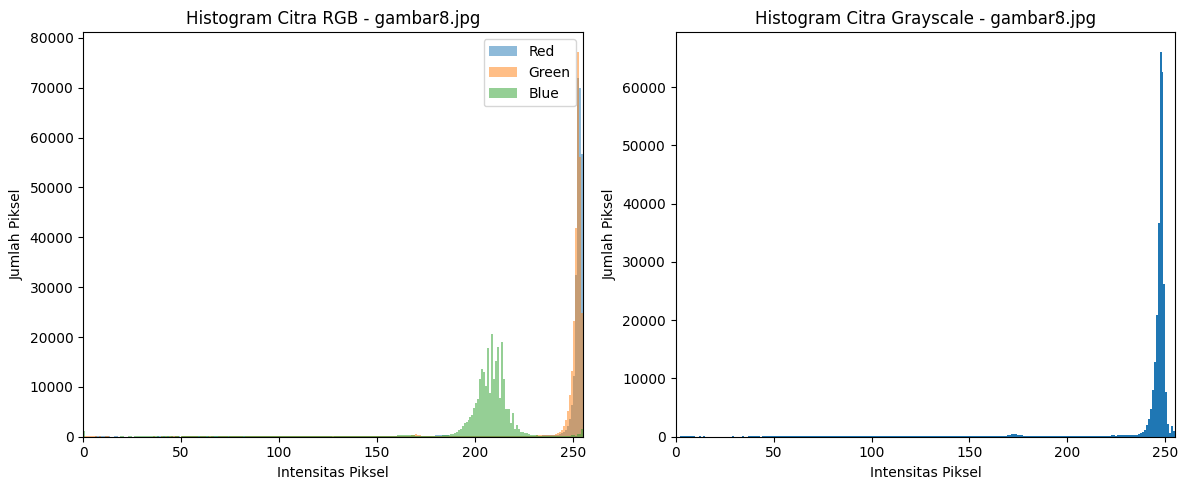

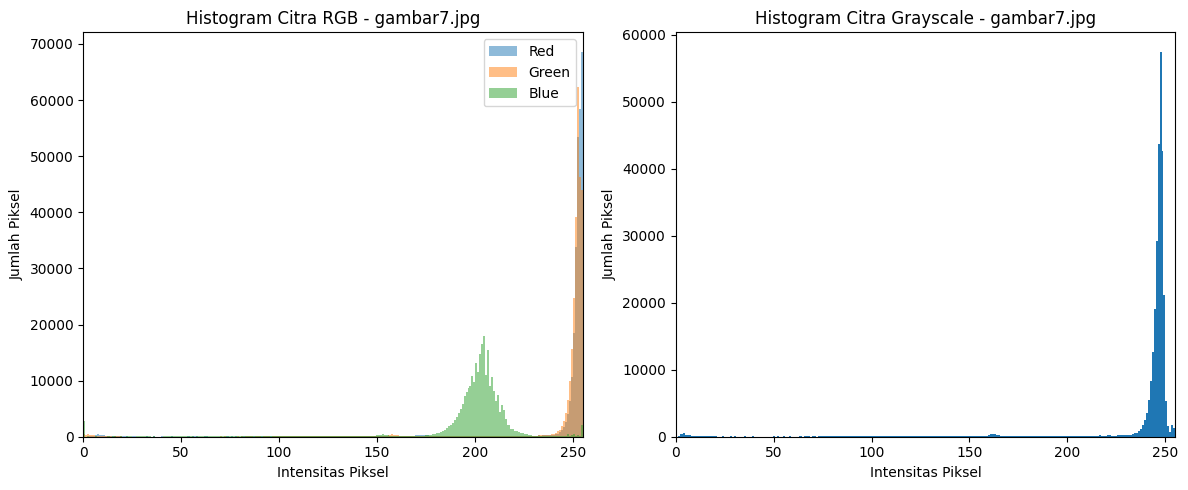

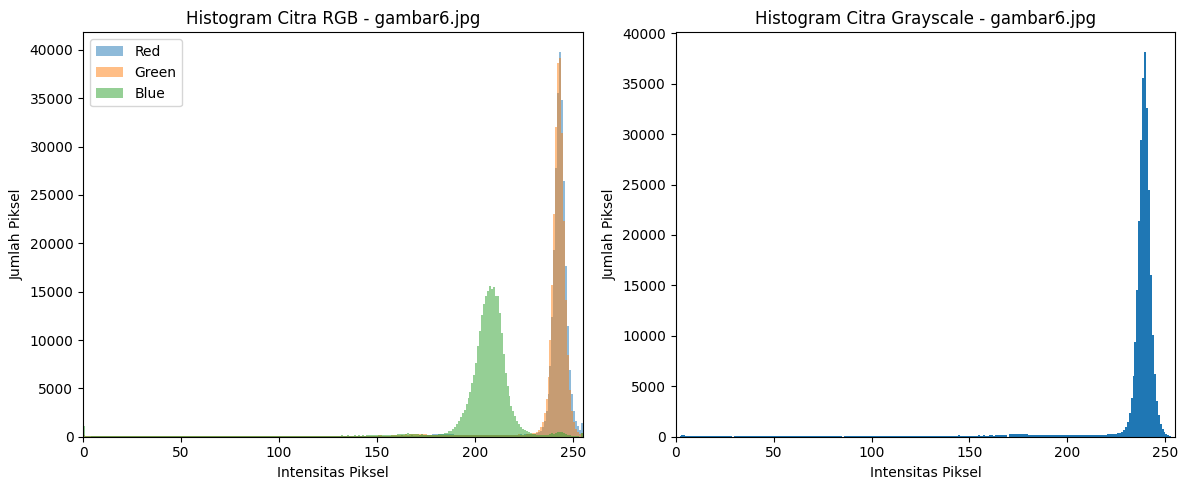

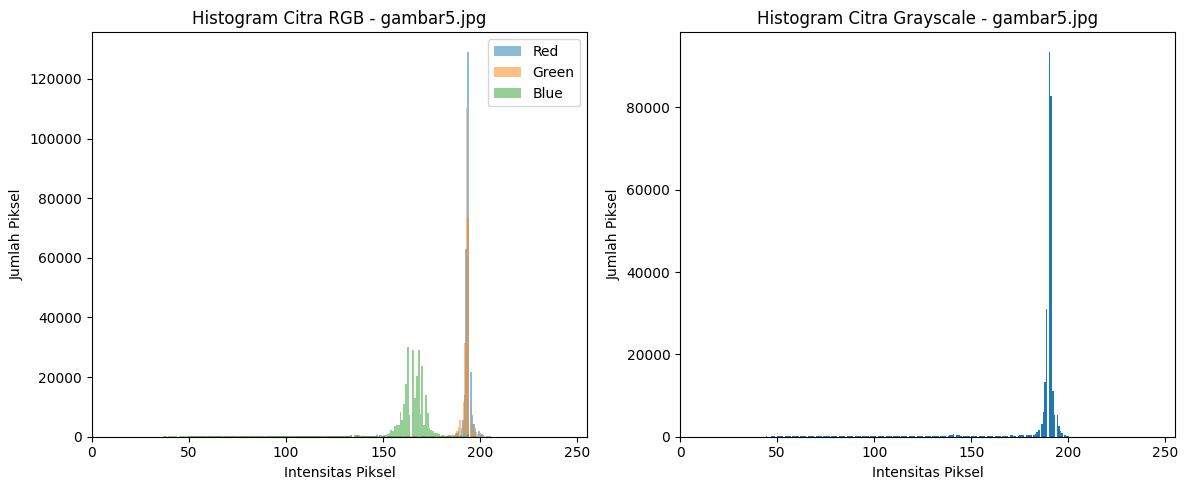

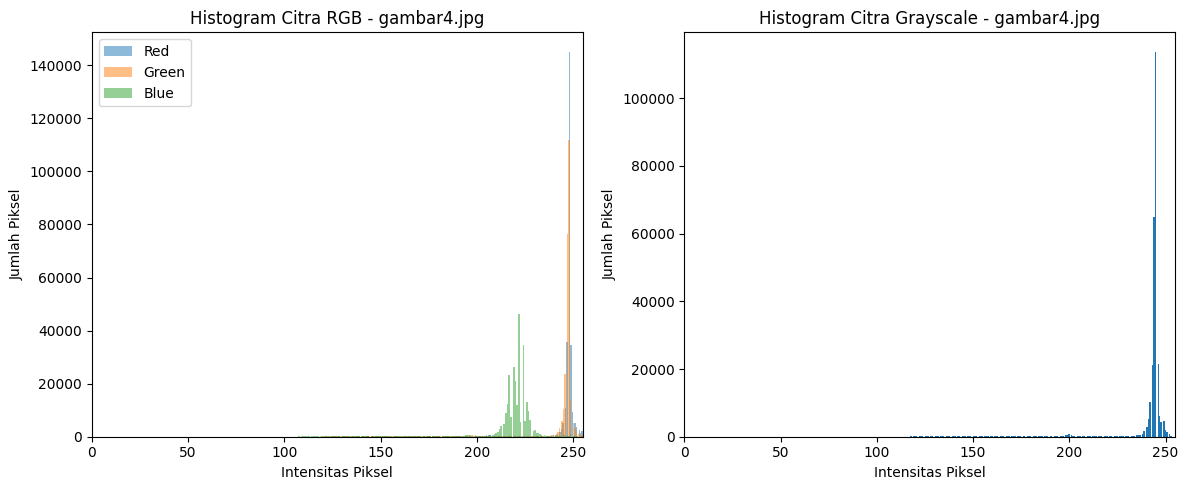

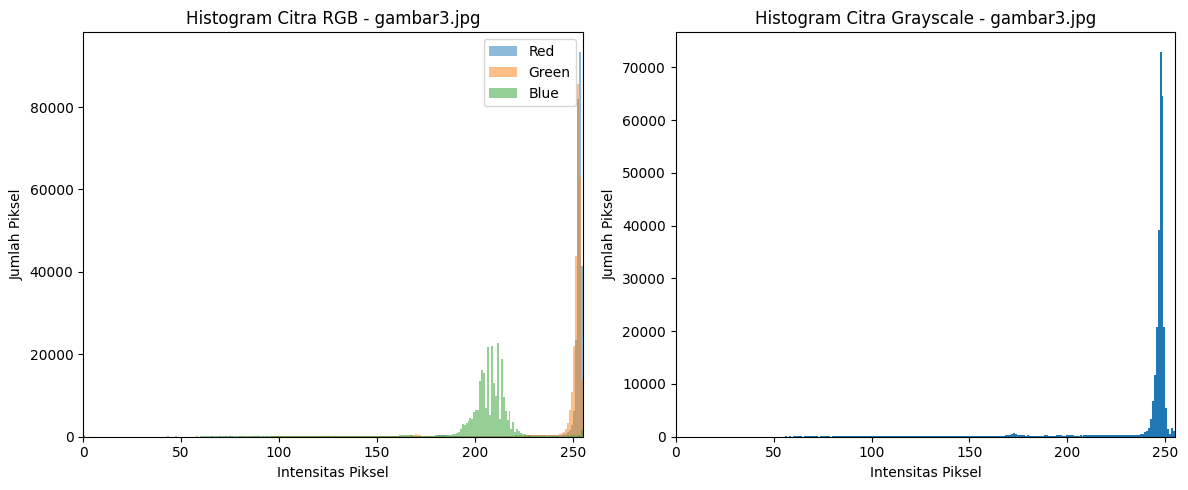

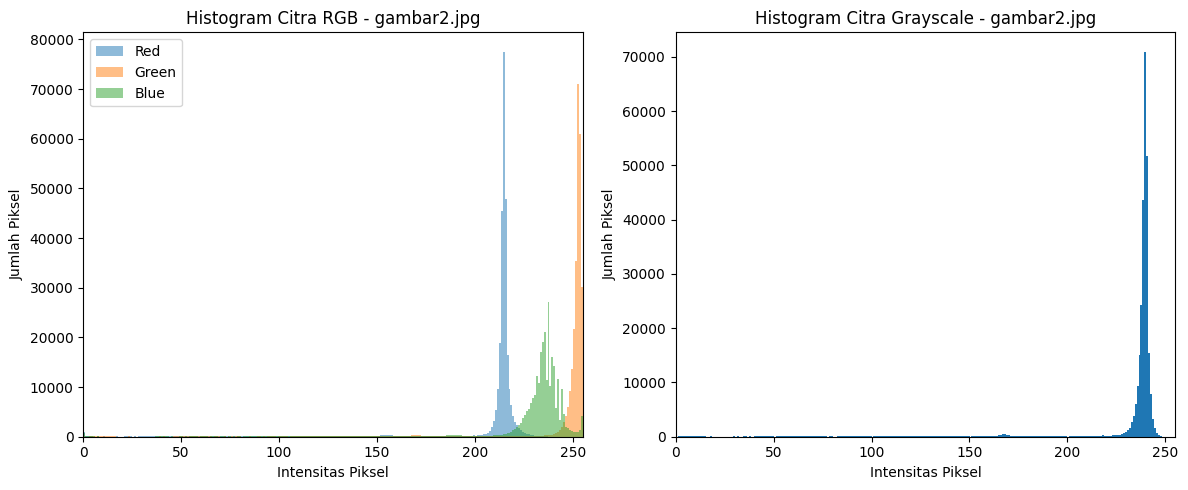

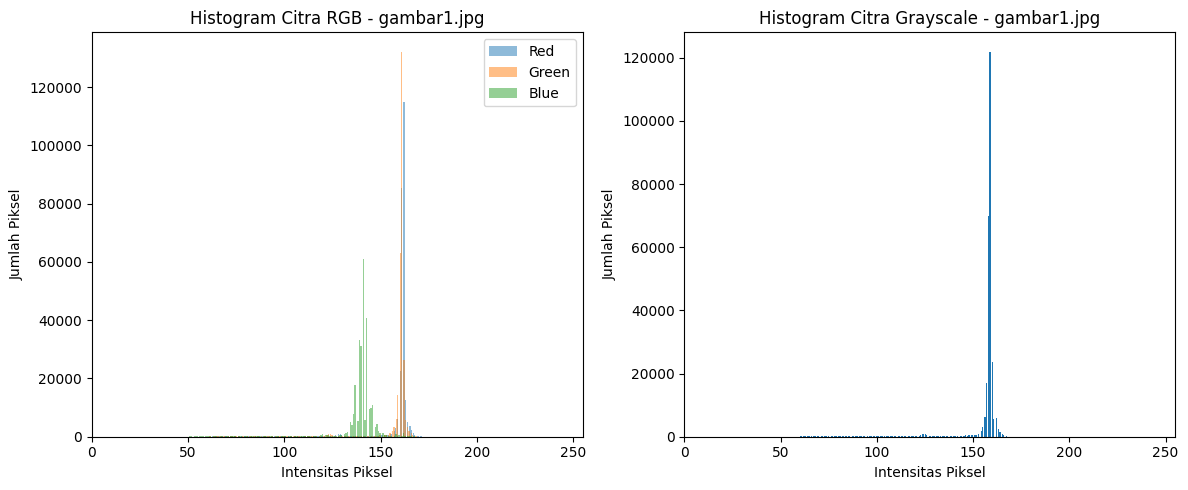

In [ ]:
for nama_file, data in data_citra.items():

    rgb = data["rgb"]
    gray = data["gray"]

    plt.figure(figsize=(12, 5))

    # Histogram RGB
    plt.subplot(1, 2, 1)

    plt.hist(rgb[:, :, 0].ravel(), bins=256, alpha=0.5, label="Red")
    plt.hist(rgb[:, :, 1].ravel(), bins=256, alpha=0.5, label="Green")
    plt.hist(rgb[:, :, 2].ravel(), bins=256, alpha=0.5, label="Blue")

    plt.title("Histogram Citra RGB - " + nama_file)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])
    plt.legend()

    # Histogram Grayscale
    plt.subplot(1, 2, 2)

    plt.hist(gray.ravel(), bins=256)

    plt.title("Histogram Citra Grayscale - " + nama_file)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.tight_layout()
    plt.show()

In [ ]:
hasil_statistik = []

for nama_file, data in data_citra.items():

    gray = data["gray"]

    mean = np.mean(gray)
    std = np.std(gray)

    persen_gelap = np.mean(gray < 60) * 100
    persen_terang = np.mean(gray > 200) * 100

    hasil_statistik.append({
        "Citra": nama_file,
        "Mean": round(mean, 2),
        "Standar Deviasi": round(std, 2),
        "Piksel Gelap (%)": round(persen_gelap, 2),
        "Piksel Terang (%)": round(persen_terang, 2)
    })

df_statistik = pd.DataFrame(hasil_statistik)

display(df_statistik)

,Citra,Mean,Standar Deviasi,Piksel Gelap (%),Piksel Terang (%)
0,gambar9.jpg,239.22,32.87,1.14,93.81
1,gambar8.jpg,239.28,32.68,0.98,93.47
2,gambar7.jpg,238.18,35.89,1.50,93.66
3,gambar6.jpg,232.13,30.51,1.01,93.65
4,gambar5.jpg,184.63,21.89,0.80,0.02
5,gambar4.jpg,239.68,19.37,0.00,95.00
6,gambar3.jpg,239.52,28.95,0.36,92.84
7,gambar2.jpg,231.58,31.61,1.15,93.47
8,gambar1.jpg,155.00,14.73,0.26,0.00


In [ ]:
def analisis_citra(gray):

    # 1. BRIGHTNESS
    mean = np.mean(gray)

    # 2. CONTRAST
    std = np.std(gray)

    # 3. CEK PENCahayaan TIDAK MERATA
    h, w = gray.shape

    bagian1 = gray[:h//2, :w//2]
    bagian2 = gray[:h//2, w//2:]
    bagian3 = gray[h//2:, :w//2]
    bagian4 = gray[h//2:, w//2:]

    rata_bagian = [
        np.mean(bagian1),
        np.mean(bagian2),
        np.mean(bagian3),
        np.mean(bagian4)
    ]

    selisih_pencahayaan = max(rata_bagian) - min(rata_bagian)

    # 4. CEK NOISE
    median = cv2.medianBlur(gray, 3)

    residual = gray.astype(np.float32) - median.astype(np.float32)

    mad = np.median(np.abs(residual - np.median(residual)))

    noise_level = 1.4826 * mad

    # 5. PERSENTASE PIXEL
    persen_gelap = np.mean(gray < 60) * 100
    persen_terang = np.mean(gray > 200) * 100

    # PENENTUAN KONDISI
    kondisi = []

    # Terlalu gelap
    if mean < 80:
        kondisi.append("Terlalu gelap")

    # Terlalu terang
    elif mean > 220:
        kondisi.append("Terlalu terang")

    # Contrast rendah
    if std < 20:
        kondisi.append("Contrast rendah")

    # Pencahayaan tidak merata
    if selisih_pencahayaan > 30:
        kondisi.append("Pencahayaan tidak merata")

    # Noise
    if noise_level > 5:
        kondisi.append("Noise")

    return {
        "mean": mean,
        "std": std,
        "persen_gelap": persen_gelap,
        "persen_terang": persen_terang,
        "selisih_pencahayaan": selisih_pencahayaan,
        "noise_level": noise_level,
        "kondisi": kondisi
    }

In [ ]:
hasil_analisis = []

for nama_file, data in data_citra.items():

    gray = data["gray"]

    hasil = analisis_citra(gray)

    hasil_analisis.append({
        "Citra": nama_file,
        "Mean": round(hasil["mean"], 2),
        "Std": round(hasil["std"], 2),
        "Piksel Gelap (%)": round(hasil["persen_gelap"], 2),
        "Piksel Terang (%)": round(hasil["persen_terang"], 2),
        "Selisih Pencahayaan": round(hasil["selisih_pencahayaan"], 2),
        "Noise Level": round(hasil["noise_level"], 2),
        "Kondisi": ", ".join(hasil["kondisi"])
    })

df_analisis = pd.DataFrame(hasil_analisis)

display(df_analisis)

,Citra,Mean,Std,Piksel Gelap (%),Piksel Terang (%),Selisih Pencahayaan,Noise Level,Kondisi
0,gambar9.jpg,239.22,32.87,1.14,93.81,3.65,1.48,Terlalu terang
1,gambar8.jpg,239.28,32.68,0.98,93.47,3.77,0.00,Terlalu terang
2,gambar7.jpg,238.18,35.89,1.50,93.66,4.00,1.48,Terlalu terang
3,gambar6.jpg,232.13,30.51,1.01,93.65,3.31,2.97,Terlalu terang
4,gambar5.jpg,184.63,21.89,0.80,0.02,2.53,0.00,Cukup baik
5,gambar4.jpg,239.68,19.37,0.00,95.00,2.17,0.00,"Terlalu terang, Contrast rendah"
6,gambar3.jpg,239.52,28.95,0.36,92.84,3.72,0.00,Terlalu terang
7,gambar2.jpg,231.58,31.61,1.15,93.47,3.41,0.00,Terlalu terang
8,gambar1.jpg,155.00,14.73,0.26,0.00,1.60,0.00,Contrast rendah


In [ ]:
def tentukan_enhancement(gray, kondisi):

    # Terlalu gelap
    if "Terlalu gelap" in kondisi:
        enhanced = gamma_correction(gray, 0.6)
        metode = "Gamma Correction (gamma < 1)"
        alasan = "Meningkatkan intensitas citra yang terlalu gelap."

    # Terlalu terang
    elif "Terlalu terang" in kondisi:
        enhanced = gamma_correction(gray, 1.5)
        metode = "Gamma Correction (gamma > 1)"
        alasan = "Menurunkan intensitas citra yang terlalu terang."

    # Pencahayaan tidak merata
    elif "Pencahayaan tidak merata" in kondisi:
        enhanced = clahe_enhancement(gray)
        metode = "CLAHE"
        alasan = "Meningkatkan kontras lokal pada area citra."

    # Contrast rendah
    elif "Contrast rendah" in kondisi:
        enhanced = contrast_stretching(gray)
        metode = "Contrast Stretching"
        alasan = "Memperluas rentang intensitas piksel."

    # Noise
    elif "Noise" in kondisi:
        enhanced = median_filter(gray)
        metode = "Median Filter"
        alasan = "Mengurangi noise pada citra."

    # Tidak ada masalah
    else:
        enhanced = gray.copy()
        metode = "Tidak ada enhancement"
        alasan = "Citra tidak menunjukkan masalah yang signifikan."

    return enhanced, metode, alasan

In [ ]:
hasil_enhancement = []

for nama_file, data in data_citra.items():

    gray = data["gray"]

    hasil = analisis_citra(gray)

    kondisi = hasil["kondisi"]

    enhanced, metode, alasan = tentukan_enhancement(
        gray,
        kondisi
    )

    hasil_enhancement.append({
        "Citra": nama_file,
        "Kondisi": ", ".join(kondisi) if kondisi else "Tidak ada masalah terdeteksi",
        "Metode Enhancement": metode,
        "Alasan": alasan
    })

    # Simpan hasil enhancement
    data["enhanced"] = enhanced


df_enhancement = pd.DataFrame(hasil_enhancement)

display(df_enhancement)

,Citra,Kondisi,Metode Enhancement,Alasan
0,gambar9.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
1,gambar8.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
2,gambar7.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
3,gambar6.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
4,gambar5.jpg,Tidak ada masalah terdeteksi,Tidak ada enhancement,Citra tidak menunjukkan masalah yang signifikan.
5,gambar4.jpg,"Terlalu terang, Contrast rendah",Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
6,gambar3.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
7,gambar2.jpg,Terlalu terang,Gamma Correction (gamma > 1),Menurunkan intensitas citra yang terlalu terang.
8,gambar1.jpg,Contrast rendah,Contrast Stretching,Memperluas rentang intensitas piksel.


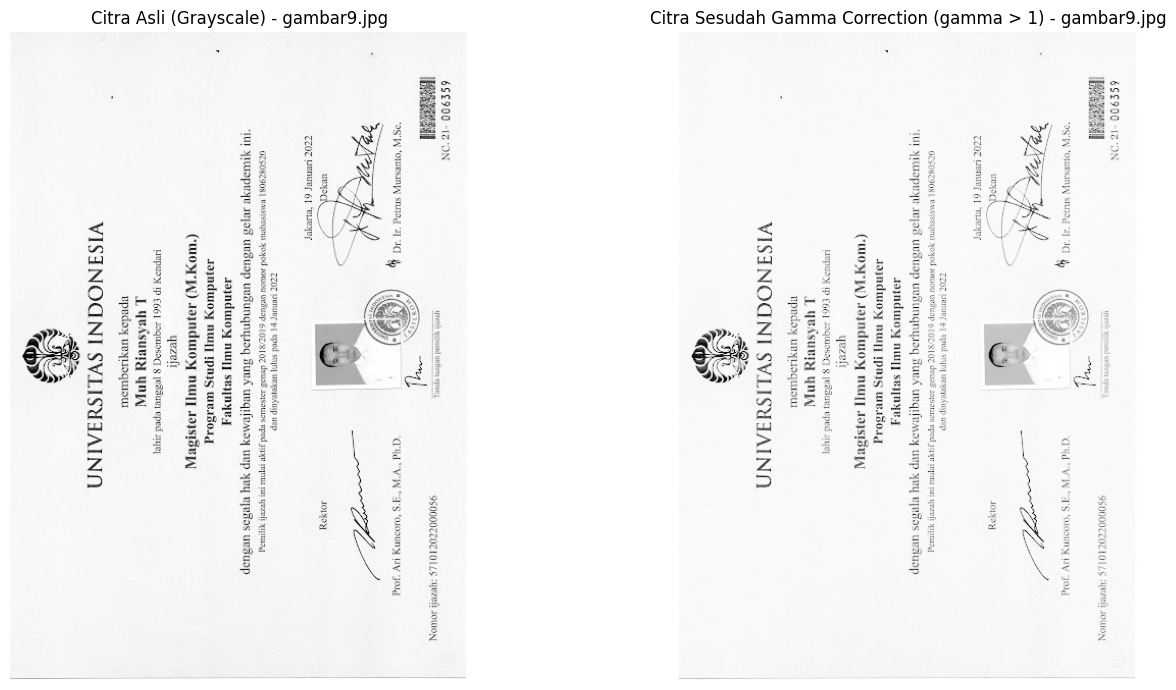

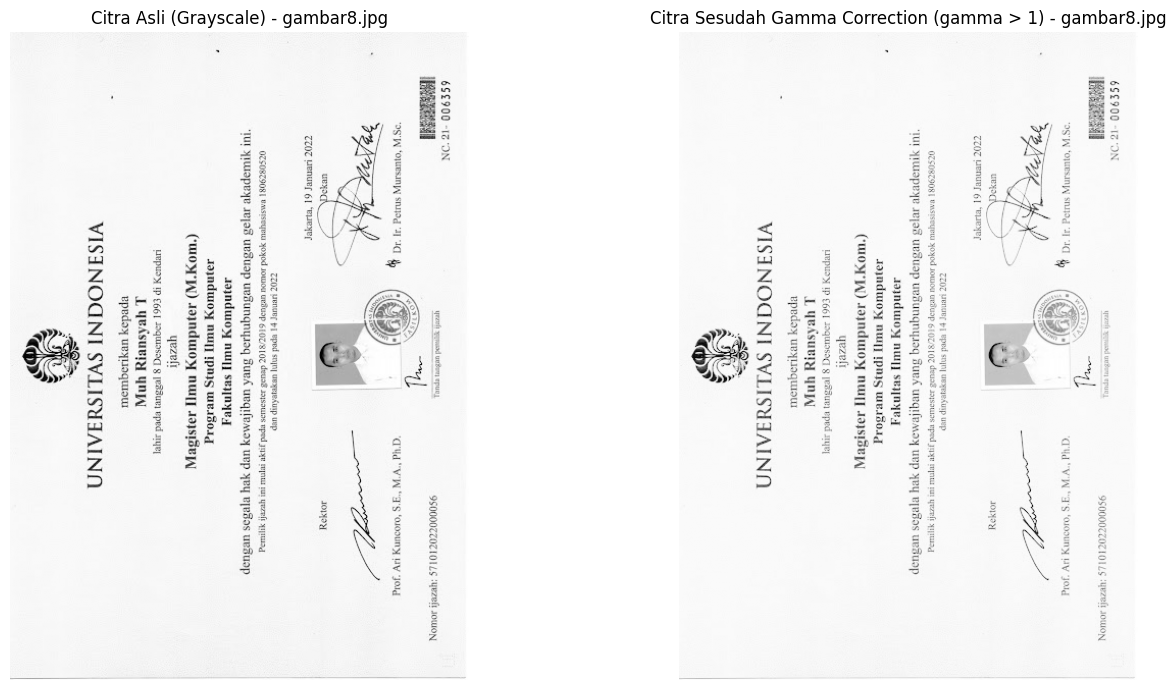

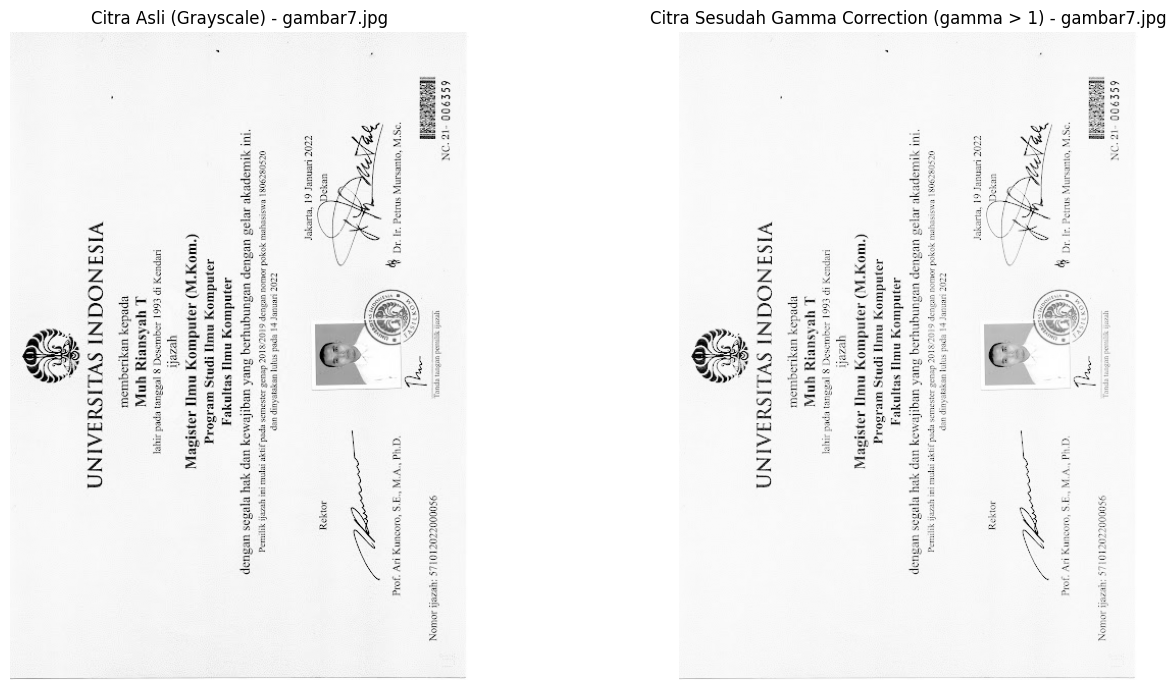

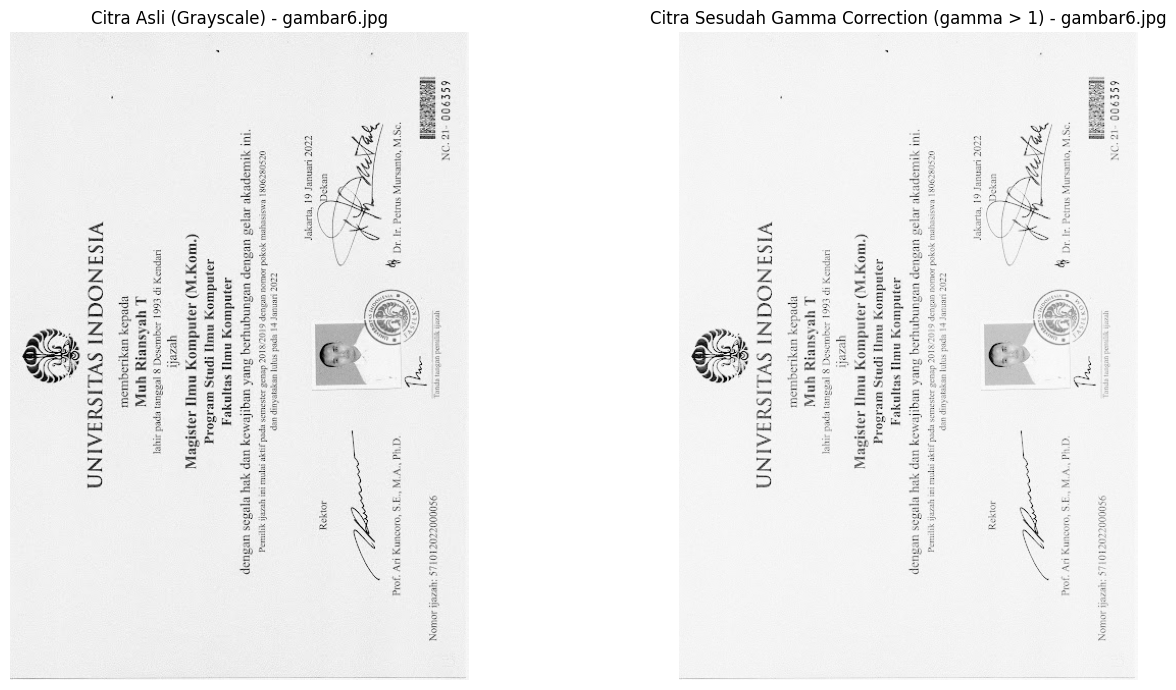

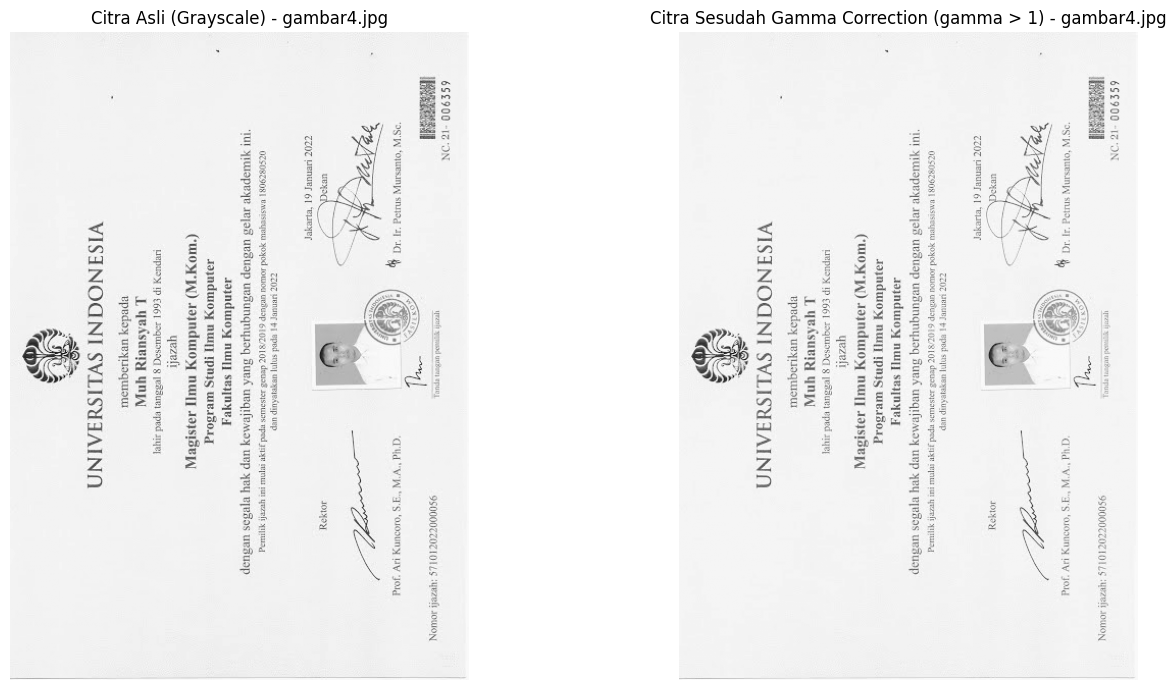

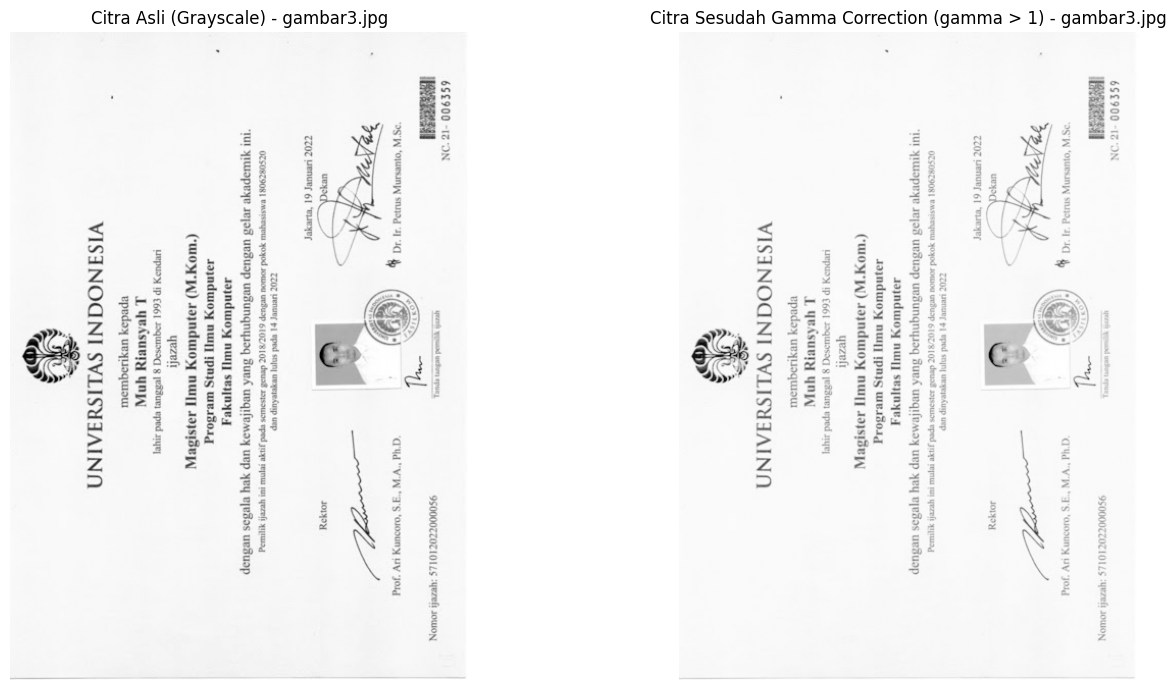

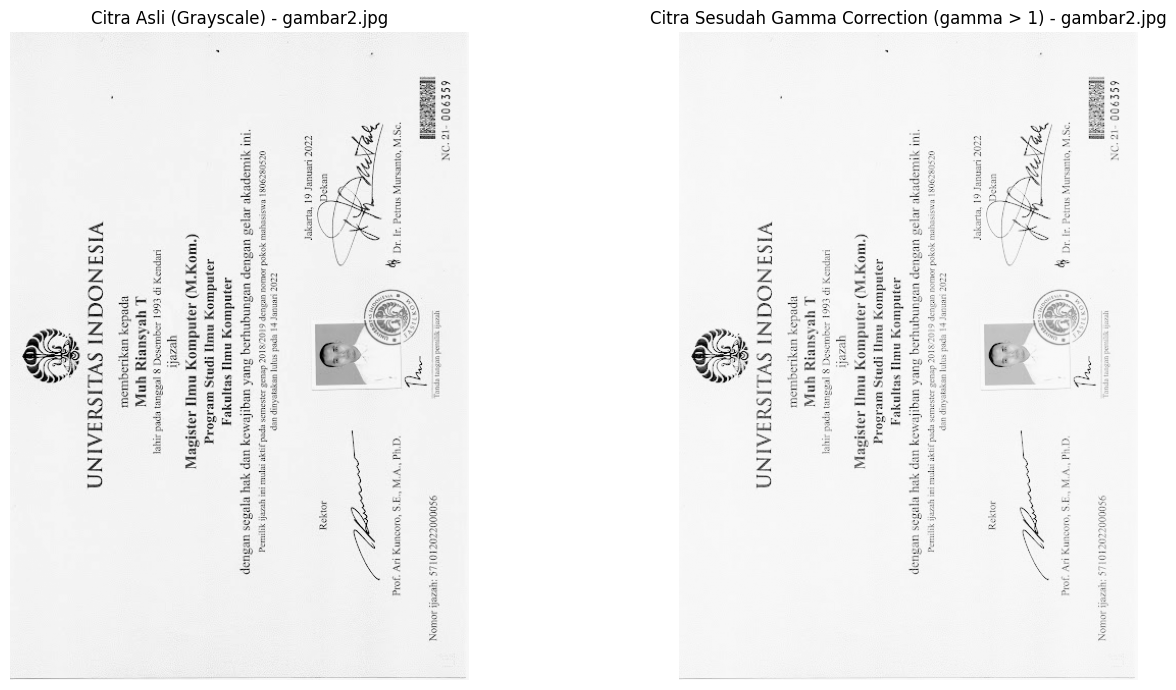

In [21]:
terlalu_terang_images = df_enhancement[(df_enhancement['Kondisi'].str.contains('Terlalu terang')) & (df_enhancement['Metode Enhancement'] == 'Gamma Correction (gamma > 1)')]

if not terlalu_terang_images.empty:
    for index, row in terlalu_terang_images.iterrows():
        nama_file = row['Citra']
        original_gray = data_citra[nama_file]['gray']
        enhanced_gamma = data_citra[nama_file]['enhanced']

        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(original_gray, cmap='gray')
        plt.title(f'Citra Asli (Grayscale) - {nama_file}')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(enhanced_gamma, cmap='gray')
        plt.title(f'Citra Sesudah Gamma Correction (gamma > 1) - {nama_file}')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Tidak ada citra yang teridentifikasi 'Terlalu terang' dan diperbaiki dengan Gamma Correction (gamma > 1).")

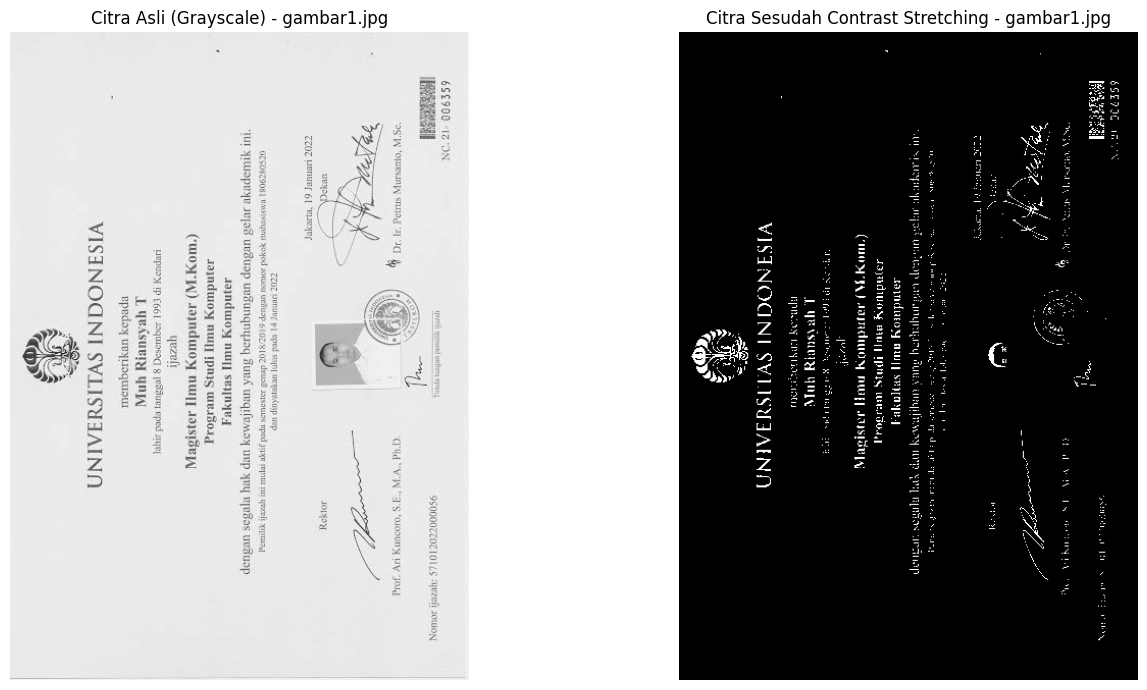

In [22]:
contrast_rendah_images = df_enhancement[(df_enhancement['Kondisi'].str.contains('Contrast rendah')) & (df_enhancement['Metode Enhancement'] == 'Contrast Stretching')]

if not contrast_rendah_images.empty:
    for index, row in contrast_rendah_images.iterrows():
        nama_file = row['Citra']
        original_gray = data_citra[nama_file]['gray']
        enhanced_contrast = data_citra[nama_file]['enhanced']

        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(original_gray, cmap='gray')
        plt.title(f'Citra Asli (Grayscale) - {nama_file}')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(enhanced_contrast, cmap='gray')
        plt.title(f'Citra Sesudah Contrast Stretching - {nama_file}')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Tidak ada citra yang teridentifikasi 'Contrast rendah' dan diperbaiki dengan Contrast Stretching.")